# 🩺 Predicting Student Health Risk
### Kaggle Playground Series - Season 6 Episode 7

**Author:** Ayesha Asif

## Objective
Build a machine learning model that predicts the health condition of students into one of three categories:

- Fit
- Unhealthy
- At-Risk

The competition is evaluated using **Balanced Accuracy**.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import balanced_accuracy_score

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
submission = pd.read_csv("../data/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", submission.shape)

Train shape: (690088, 15)
Test shape: (295753, 14)
Submission shape: (295753, 2)


In [4]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [6]:
print(train["health_condition"].value_counts())
print("\nClass percentages:")
print(train["health_condition"].value_counts(normalize=True) * 100)

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

Class percentages:
health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64


In [7]:
missing_values = train.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

stress_level               82811
sleep_duration             75999
sleep_quality              58331
calorie_expenditure        52853
water_intake               43477
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
step_count                 13916
bmi                        13898
heart_rate                  7833
diet_type                   6901
exercise_duration           6901
dtype: int64

In [8]:
train.shape
train.head()
train.info()
train["health_condition"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

health_condition
at-risk      592561
unhealthy     57724
fit           39803
Name: count, dtype: int64

In [9]:
train.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [10]:
train.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

In [11]:
numerical_columns = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
['id', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Categorical Columns
['health_condition', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


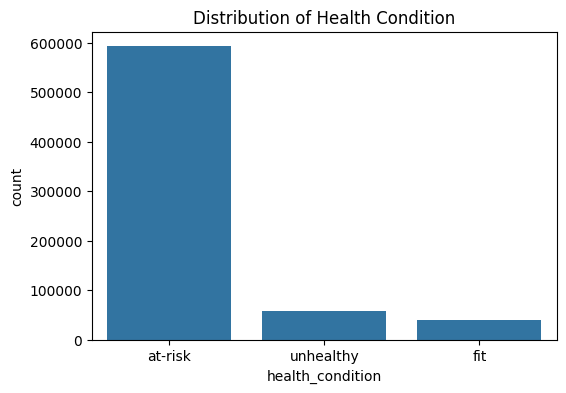

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="health_condition",
    order=train["health_condition"].value_counts().index
)

plt.title("Distribution of Health Condition")
plt.show()

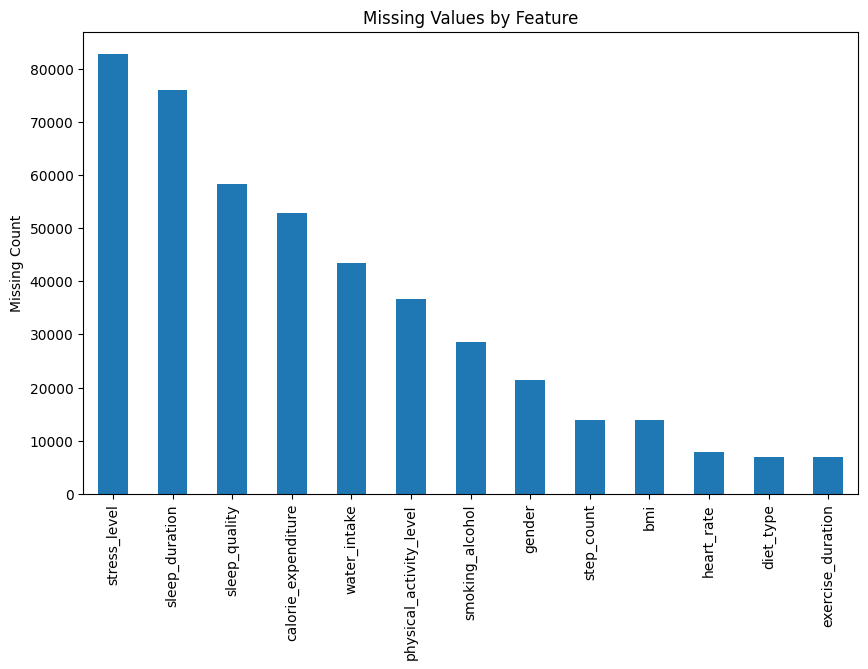

In [13]:
missing = (
    train.isnull()
         .sum()
         .sort_values(ascending=False)
)

missing = missing[missing > 0]

plt.figure(figsize=(10,6))

missing.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.ylabel("Missing Count")
plt.show()

In [14]:
X = train.drop(columns=["health_condition"])
y = train["health_condition"]

X_test = test.copy()

In [15]:
X = X.drop(columns=["id"])
X_test = X_test.drop(columns=["id"])

In [16]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numeric:", list(numeric_features))
print("\nCategorical:", list(categorical_features))

Numeric: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Categorical: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

In [18]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['at-risk' 'fit' 'unhealthy']


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_valid.shape)

(552070, 13)
(138018, 13)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score

In [22]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [23]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
y_pred = rf_model.predict(X_valid)

In [25]:
y_pred = rf_model.predict(X_valid)

In [26]:
score = balanced_accuracy_score(y_valid, y_pred)

print(f"Balanced Accuracy: {score:.5f}")

Balanced Accuracy: 0.85278


In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_valid,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

     at-risk       0.97      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.98      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.97      0.85      0.90    138018
weighted avg       0.97      0.97      0.96    138018



In [28]:
test_predictions = rf_model.predict(X_test)

test_labels = label_encoder.inverse_transform(test_predictions)

In [29]:
submission["health_condition"] = test_labels

submission.to_csv("submission_rf.csv", index=False)

print("Submission file created successfully!")

Submission file created successfully!


In [30]:
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [31]:
from catboost import CatBoostClassifier

In [32]:
cat_features = [
    X.columns.get_loc(col)
    for col in categorical_features
]

print(cat_features)

[7, 8, 9, 10, 11, 12]


In [33]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()

# Fill numeric columns with median
for col in numeric_features:
    median = X_train_cb[col].median()

    X_train_cb[col] = X_train_cb[col].fillna(median)
    X_valid_cb[col] = X_valid_cb[col].fillna(median)
    X_test_cb[col] = X_test_cb[col].fillna(median)

# Fill categorical columns with most frequent value
for col in categorical_features:
    mode = X_train_cb[col].mode()[0]

    X_train_cb[col] = X_train_cb[col].fillna(mode)
    X_valid_cb[col] = X_valid_cb[col].fillna(mode)
    X_test_cb[col] = X_test_cb[col].fillna(mode)

In [34]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    verbose=100
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features
)

0:	learn: 1.0158984	total: 4.18s	remaining: 34m 44s
100:	learn: 0.1213112	total: 6m 35s	remaining: 26m 4s
200:	learn: 0.1147884	total: 11m 59s	remaining: 17m 50s
300:	learn: 0.1132608	total: 16m 44s	remaining: 11m 3s
400:	learn: 0.1118958	total: 21m 46s	remaining: 5m 22s
499:	learn: 0.1108835	total: 26m 49s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='MultiClass', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [35]:
cat_pred = cat_model.predict(X_valid_cb)

cat_pred = cat_pred.astype(int).flatten()

cat_score = balanced_accuracy_score(
    y_valid,
    cat_pred
)

print(f"CatBoost Balanced Accuracy: {cat_score:.5f}")

CatBoost Balanced Accuracy: 0.85640


In [36]:
print(
    classification_report(
        y_valid,
        cat_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

     at-risk       0.97      1.00      0.98    118512
         fit       0.95      0.80      0.87      7961
   unhealthy       0.97      0.77      0.86     11545

    accuracy                           0.97    138018
   macro avg       0.96      0.86      0.90    138018
weighted avg       0.97      0.97      0.96    138018



In [37]:
test_pred_cb = cat_model.predict(X_test_cb)

test_pred_cb = test_pred_cb.astype(int).flatten()

test_labels_cb = label_encoder.inverse_transform(test_pred_cb)

submission_cb = pd.DataFrame({
    "id": test["id"],
    "health_condition": test_labels_cb
})

submission_cb.to_csv(
    "submission_catboost.csv",
    index=False
)

print("CatBoost submission created!")
submission_cb.head()

CatBoost submission created!


,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


In [38]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

print(weights)

[0.38819475 5.77926428 3.9850004 ]


In [39]:
cat_model2 = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=10,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_seed=42,
    class_weights=weights,
    early_stopping_rounds=100,
    verbose=100
)

cat_model2.fit(
    X_train_cb,
    y_train,
    eval_set=(X_valid_cb, y_valid),
    cat_features=cat_features
)

0:	learn: 1.0528775	test: 1.0528749	best: 1.0528749 (0)	total: 3.94s	remaining: 1h 5m 35s
100:	learn: 0.2542718	test: 0.2575693	best: 0.2575693 (100)	total: 8m 34s	remaining: 1h 16m 22s
200:	learn: 0.2250487	test: 0.2354385	best: 0.2354385 (200)	total: 17m 11s	remaining: 1h 8m 21s
300:	learn: 0.2162651	test: 0.2330501	best: 0.2330501 (300)	total: 28m 25s	remaining: 1h 5m 59s
400:	learn: 0.2089767	test: 0.2323436	best: 0.2323436 (400)	total: 40m 30s	remaining: 1h 30s
500:	learn: 0.2014843	test: 0.2319749	best: 0.2319749 (500)	total: 52m 58s	remaining: 52m 46s
600:	learn: 0.1942794	test: 0.2318319	best: 0.2318319 (600)	total: 1h 5m 21s	remaining: 43m 23s
700:	learn: 0.1871873	test: 0.2320797	best: 0.2318319 (600)	total: 1h 18m 16s	remaining: 33m 23s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.2318318713
bestIteration = 600

Shrink model to first 601 iterations.


CatBoostClassifier(class_weights=array([0.38819475, 5.77926428, 3.9850004 ]), depth=10, early_stopping_rounds=100, eval_metric='MultiClass', iterations=1000, learning_rate=0.03, loss_function='MultiClass', random_seed=42, verbose=100)

In [41]:
# Predict validation set
cat_pred_v2 = cat_model2.predict(X_valid_cb)
cat_pred_v2 = cat_pred_v2.astype(int).flatten()

# Check balanced accuracy
cat_score_v2 = balanced_accuracy_score(y_valid, cat_pred_v2)
print(f"Tuned CatBoost Balanced Accuracy: {cat_score_v2:.5f}")

Tuned CatBoost Balanced Accuracy: 0.90756


In [42]:
# Predict test set
test_pred_v2 = cat_model2.predict(X_test_cb)
test_pred_v2 = test_pred_v2.astype(int).flatten()

# Convert numeric predictions back to class labels
test_labels_v2 = label_encoder.inverse_transform(test_pred_v2)

# Build submission file
submission_v2 = pd.DataFrame({
    "id": test["id"],
    "health_condition": test_labels_v2
})

# Save CSV
submission_v2.to_csv("submission_catboost_v2.csv", index=False)

print("submission_catboost_v2.csv created successfully!")
submission_v2.head()

submission_catboost_v2.csv created successfully!


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
